Ejercicio 1a 

Para obtener mayor precisión, quiero datos no redundantes y curados. Para ello voy a filtrar los resultados con refSeq

1) Busco en protein y filtro por organism, pdat, slen y refSeq. Me arroja 35 resultados.
2) Busco en nucleotide y filtro por organism, properties, refSeq y uso attenuator como palabra clave. Me arroja 126 resultados.
3) Busco en protein y filtro por organism, refSeq y uso penicillin-binding como palabra clave. Me arroja 1219 resultados.
   Busco en gene y hago lo mismo. Me arroja 9 resultados.
   Busco en nucleotide y hago lo mismo. Me arroja 37 resultados.
4) Busco en nucleotide y filtro por autor, properties y refSeq. Me arroja 23782 resultados (pero no filtro si los subió o lo mencionan)

Ejercicio 1b

1) Locus tiene el gen, la cantidad de aminoácidos y la forma de la estructura
   Definition que dice el nombre y al organismo al que pertenece
   Accession me da el nombre correcto de la secuencia
   Source es de donde viene
   siguen las referencias
   Abajo hay un comentario y al final esta la secuencia.
2) La mioglobina tiene una longitud de 154 aminoácidos.
3) Tiene una longitud de 1170 pares de bases.
4) Existen 9 variantes.
5) Se encuentra en el cromosoma 22, en el brazo largo y la banda 22q11.23. Aledaños se encuentran los genes APOL6 y RASD2.
6) AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAYa no existe esa sección o que onda

Ejercicio 1c

1) Me fijo en PTM, veo que existen fosforilaciones en serina, treonina y tirosina, y acetilaciones en lisina.
2) Busco en genomic coordinates y leo que se localiza en el cromosoma 22, y tiene 3 exones.
3) En la seccion structure puedo ver que existe una estructura hecha con x-ray. Su código es 3RGK.
4) Hay una sección history que tiene un historial. Ahí se puede ver que la primera vez que se registró fue el 01/11/1988, en la base Swiss-Prot

In [84]:
#Elementos para utilizar en el código

import random
import numpy as np
import matplotlib.pyplot as plt
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
from Bio import SeqIO, Entrez, ExPASy, SwissProt

bases = ["A","C","G","T"]

aminoacidos = ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"]

codones_a_aminoacidos = {
    # Alanina
    "GCT": "A", "GCC": "A", "GCA": "A", "GCG": "A",
    # Cisteína
    "TGT": "C", "TGC": "C",
    # Ácido aspártico
    "GAT": "D", "GAC": "D",
    # Ácido glutámico
    "GAA": "E", "GAG": "E",
    # Fenilalanina
    "TTT": "F", "TTC": "F",
    # Glicina
    "GGT": "G", "GGC": "G", "GGA": "G", "GGG": "G",
    # Histidina
    "CAT": "H", "CAC": "H",
    # Isoleucina
    "ATT": "I", "ATC": "I", "ATA": "I",
    # Lisina
    "AAA": "K", "AAG": "K",
    # Leucina
    "TTA": "L", "TTG": "L", "CTT": "L", "CTC": "L", "CTA": "L", "CTG": "L",
    # Metionina
    "ATG": "M",
    # Asparagina
    "AAT": "N", "AAC": "N",
    # Prolina
    "CCT": "P", "CCC": "P", "CCA": "P", "CCG": "P",
    # Glutamina
    "CAA": "Q", "CAG": "Q",
    # Arginina
    "CGT": "R", "CGC": "R", "CGA": "R", "CGG": "R", "AGA": "R", "AGG": "R",
    # Serina
    "TCT": "S", "TCC": "S", "TCA": "S", "TCG": "S", "AGT": "S", "AGC": "S",
    # Treonina
    "ACT": "T", "ACC": "T", "ACA": "T", "ACG": "T",
    # Valina
    "GTT": "V", "GTC": "V", "GTA": "V", "GTG": "V",
    # Triptofano
    "TGG": "W",
    # Tirosina
    "TAT": "Y", "TAC": "Y",
    # Stop (le ponemos X que no es un aminoácido)
    "TAA": "*", "TAG": "*", "TGA": "*"
}

mioglobina_prot = "MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKIPVKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYKELGFQG"


In [85]:
#Ejercicio 2.1.I

def genera_secuencia(longitud: int) -> str:
    seq = ""
    for i in range(longitud):
        seq += random.choice(bases)
    return seq

genera_secuencia(10)

'TTTCATTTCT'

In [86]:
#Ejercicio 2.1.II

def genera_proteina(longitud: int) -> str:
    proteina = ""
    for i in range(longitud):
        proteina += random.choice(aminoacidos)
    return proteina

genera_proteina(20)

'NSPMVLGHVKCIRDDQCYYY'

In [87]:
#Ejercicio 2.1.III

def prob_genera_proteina(longitud: int) -> str:
    probabilidades = {
    'A': 0.01, 'C': 0.01, 'D': 0.01, 'E': 0.01, 'F': 0.41,
    'G': 0.01, 'H': 0.01, 'I': 0.01, 'K': 0.01, 'L': 0.41,
    'M': 0.01, 'N': 0.01, 'P': 0.01, 'Q': 0.01, 'R': 0.01,
    'S': 0.01, 'T': 0.01, 'V': 0.01, 'W': 0.01, 'Y': 0.01
    }
    proteina = ""
    for i in range(longitud):
        proteina += np.random.choice(aminoacidos, p=list(probabilidades.values()))
    return proteina

prob_genera_proteina(20)

'FFFQFFFLFFDRFLFFFSFF'

In [88]:
#Ejercicio 2.2.I

def calcula_frecuencia(proteina: str) -> dict[str, float]:
    frecuencias = {}
    for amino in proteina:
        if amino not in frecuencias:
            frecuencias[amino] = 0
        frecuencias[amino] += 1
    longitud = len(proteina)
    for amino in frecuencias:
        frecuencias[amino] = frecuencias[amino] * 100 / longitud
    return frecuencias

calcula_frecuencia('VDGEWKWENQIREMEFLCTKA')

{'V': 4.761904761904762,
 'D': 4.761904761904762,
 'G': 4.761904761904762,
 'E': 19.047619047619047,
 'W': 9.523809523809524,
 'K': 9.523809523809524,
 'N': 4.761904761904762,
 'Q': 4.761904761904762,
 'I': 4.761904761904762,
 'R': 4.761904761904762,
 'M': 4.761904761904762,
 'F': 4.761904761904762,
 'L': 4.761904761904762,
 'C': 4.761904761904762,
 'T': 4.761904761904762,
 'A': 4.761904761904762}

IHYCKDQPDTPRQAKPVIEIASILGGDSDC


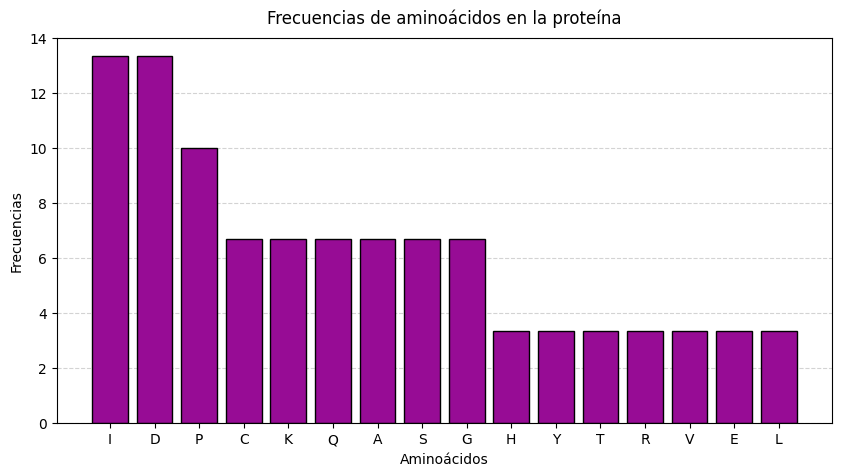

In [89]:
#Ejercicio 2.2.II

def graficar(items: dict[str, int], titulo: str, eje_x: str, eje_y: str) -> plt:
    datos = sorted(items.items(), key=lambda x: x[1], reverse=True)
    elementos = [x[0] for x in datos]
    valores = [x[1] for x in datos]
    plt.figure(figsize=(10,5))
    plt.bar(elementos, valores, color="#970c95", edgecolor="black", zorder=2)
    plt.grid(axis="y", linestyle="--", color="lightgrey", zorder=1)
    plt.title(titulo, pad=10)
    plt.xlabel(eje_x)
    plt.ylabel(eje_y)
    plt.show()

proteina = genera_proteina(30)
print(proteina)
frecuencias = calcula_frecuencia(proteina)
graficar(frecuencias,
         "Frecuencias de aminoácidos en la proteína",
         "Aminoácidos", "Frecuencias")

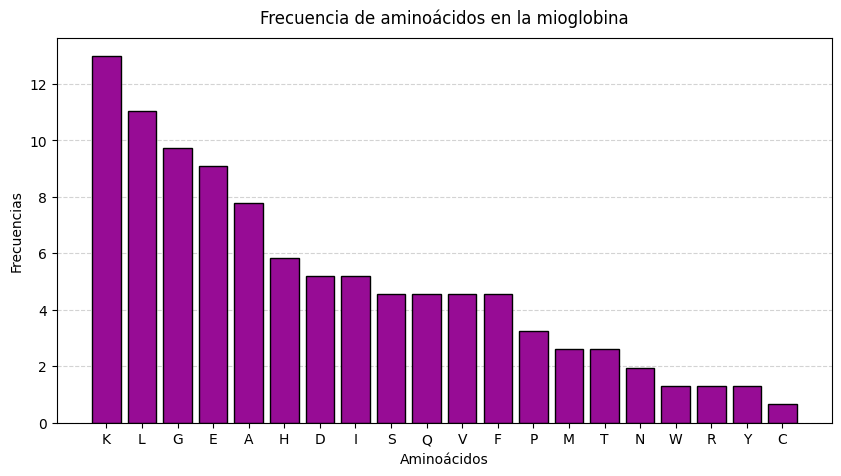

In [90]:
#Ejercicio 2.2.III (mioglobina por aminoácidos)

graficar(calcula_frecuencia(mioglobina_prot),
        "Frecuencia de aminoácidos en la mioglobina",
        "Aminoácidos", "Frecuencias")

In [91]:
#Ejercicio 3.1.a AAAAAAAAA

def complementar(seq: Seq) -> Seq:
    return seq.complement()

complementar(Seq("AAAGGTC"))

Seq('TTTCCAG')

In [92]:
#Ejercicio 3.1.b AAAAAAAAAA

In [93]:
#Ejercicio 3.2.a
mioglobina_file = SeqIO.read("/home/pizza/Escritorio/Bioinformática/TP 1/sequence.gp", "genbank")
print(mioglobina_file.name)
print(mioglobina_file.id)
print(mioglobina_file.seq)

NP_976311
NP_976311.1
MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKIPVKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYKELGFQG


In [94]:
#Ejercicio 3.2.b

id_mioglobina = mioglobina_file.id
Entrez.email= "manelmontalat@gmail.com"
handle = Entrez.efetch(db="protein", id=id_mioglobina, rettype="fasta", retmode="text")
mioglobina_fasta = SeqIO.read(handle, "fasta")
handle.close()
print(mioglobina_fasta.seq)

MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKIPVKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYKELGFQG


In [95]:
#Ejercicio 3.3.a registro???

handle2 = ExPASy.get_sprot_raw("P02144")
mioglobina_uniprot = SwissProt.read(handle2)
handle2.close()
print(mioglobina_uniprot.description)

RecName: Full=Myoglobin {ECO:0000303|PubMed:5285572}; AltName: Full=Nitrite reductase MB {ECO:0000305|PubMed:32891753}; EC=1.7.-.- {ECO:0000269|PubMed:32891753}; AltName: Full=Pseudoperoxidase MB {ECO:0000305|PubMed:34679218}; EC=1.11.1.- {ECO:0000269|PubMed:34679218};


In [96]:
#Ejercicio 3.3.b
#Si descargo y uso swissprot, la funcion .sequence me lo devuelve en string directamente


MLTKHSRGYQWTSDRLREGVRS*LRKGAIITSATSQMVLK*DSLQRGRGTAKRPRIGRHQCLNKD*FLARC*HPRYRTGTEKGTGTN*PLWGS*KSDTVKALSS*NQAVCALAGLGCVQNRPESASNLASVYRRGYLSCCVRSAAASEHDGLPGSVGLLSLPTYT*EEWIDLIPLDFCRELTRRCAFNYEQI*NLRLRPHAAER**YSLTRRR*GLPSKSGLLAMNLQSMETILPRPRSIFPMHKHDPCSSSRGTWKDSLAFLIAGLRVR


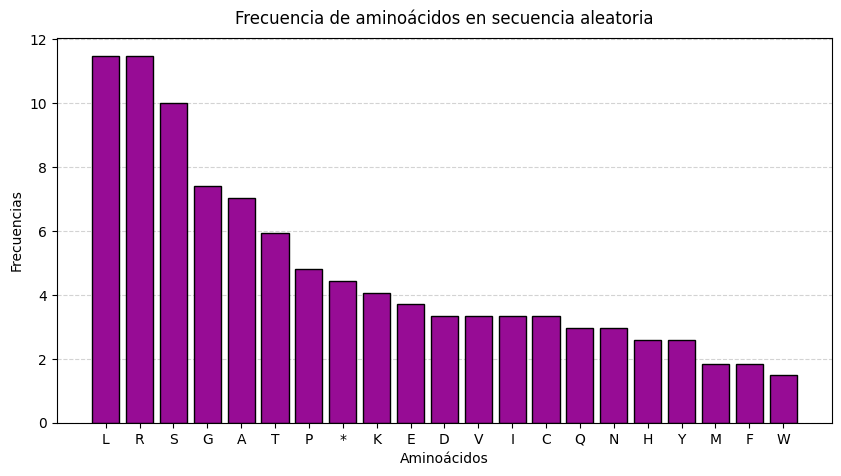

In [97]:
#Ejercicio 4.1.a

secuencia_traducida = Seq(genera_secuencia(810)).translate()
print(secuencia_traducida)
frecuencia_secuencia = calcula_frecuencia(secuencia_traducida)
graficar(frecuencia_secuencia, "Frecuencia de aminoácidos en secuencia aleatoria",
         "Aminoácidos", "Frecuencias")

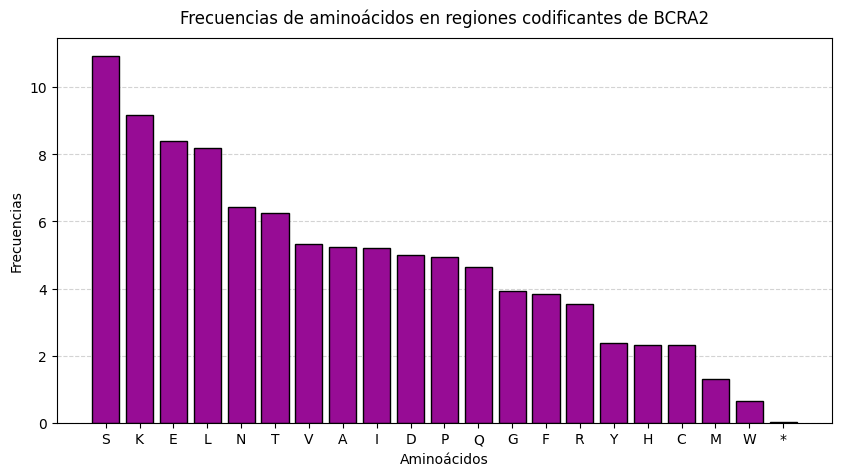

In [98]:
#Ejercicio 4.1.b

#Vamos a bajar Homo sapiens BRCA2 DNA repair associated (BRCA2), RefSeqGene (LRG_293) on chromosome 13 y luego juntar sus regiones codificantes
#No puedo bajar un mrna porque no pide eso la consigna
#Tengo que unir las regiones codificantes

handle_BCRA2 = Entrez.efetch(db="nucleotide", id="NG_012772", rettype="gb", retmode="text")
BCRA2_file = SeqIO.read(handle_BCRA2, "genbank")
handle_BCRA2.close()

def adquirir_regiones_codificantes(record: SeqRecord) -> Seq:
    cds_list = []
    for feature in record.features:
        if feature.type == "CDS":
            sec = feature.extract(record.seq)
            cds_list.append(sec)
    if len(cds_list) > 1:
        cds = sum(cds_list, Seq(""))
    return cds

BCRA2_codificante = adquirir_regiones_codificantes(BCRA2_file)
BCRA2_traducido = BCRA2_codificante.translate()
BCRA2_frecuencia = calcula_frecuencia(BCRA2_traducido)
graficar(BCRA2_frecuencia, "Frecuencias de aminoácidos en regiones codificantes de BCRA2","Aminoácidos", "Frecuencias")

Se puede ver que existe un codón ya que se encarga de terminar de traducir la proteína. Similar a las secuencias aleatorias, hay poca presencia de metioninas y triptofanos, y alta presencia de serinas y leucinas.

In [99]:
#Ejercicio 4.1.c NO SE ENTIENDE LA CONSIGNA

Ejercicio 4.1.d

El código genético muestra que hay varios aminoácidos que son generados por mas de un codón, como la leucina, serina, arginina, valina y prolina. En cambio, la metionina y el triptofano están generados por un solo codón. Esto quiere decir que en una secuencia al azar, es mas probable que aparezcan aminoácidos que son generados por multiples codones. Si vemos la secuencia analizada previamente, se observan pocas apariciones de metionina y triptofano, y mucha presencia de serina, arginina, valina, leucina y prolina, lo que cuadra con lo deducido en el código genético.

In [100]:
#Ejercicio 4.2 no se si está terminado

from urllib.request import urlopen

url = "https://rest.uniprot.org/uniprotkb/search?query=organism_id:83333&format=list"

response = urlopen(url)
data = response.read().decode("utf-8")

ids = data.strip().split("\n")

print("Cantidad de proteínas:", len(ids))

Cantidad de proteínas: 25
